In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/home/mynk/Machine_learning_journey/Datasets/city_day.csv')
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [4]:
df.shape

(29531, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.dropna(subset=["AQI"])

In [9]:
df.drop(columns=["Xylene"], inplace=True)

In [10]:
df["PM10"].describe()

count    17764.000000
mean       118.454435
std         89.487976
min          0.030000
25%         56.777500
50%         96.180000
75%        150.182500
max        917.080000
Name: PM10, dtype: float64

In [11]:
df["PM10"] = df["PM10"].fillna(df["PM10"].median())

In [12]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
count,24172.000000,24850.000000,24463.000000,24459.000000,22993.000000,18314.000000,24405.000000,24245.000000,24043.000000,21315.000000,19024.000000,24850.000000
mean,67.476613,112.102860,17.622421,28.978391,32.289012,23.848366,2.345267,14.362933,34.912885,3.458668,9.525714,166.463581
std,63.075398,76.325808,22.421138,24.627054,30.712855,25.875981,7.075208,17.428693,21.724525,16.036020,20.881085,140.696585
min,0.040000,0.030000,0.030000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,13.000000
25%,29.000000,71.780000,5.660000,11.940000,13.110000,8.960000,0.590000,5.730000,19.250000,0.230000,1.027500,81.000000
50%,48.785000,96.180000,9.910000,22.100000,23.680000,16.310000,0.930000,9.220000,31.250000,1.290000,3.575000,118.000000
75%,80.925000,122.957500,20.030000,38.240000,40.170000,30.360000,1.480000,15.140000,46.080000,3.340000,10.180000,208.000000
max,914.940000,917.080000,390.680000,362.210000,378.240000,352.890000,175.810000,186.080000,257.730000,455.030000,454.850000,2049.000000


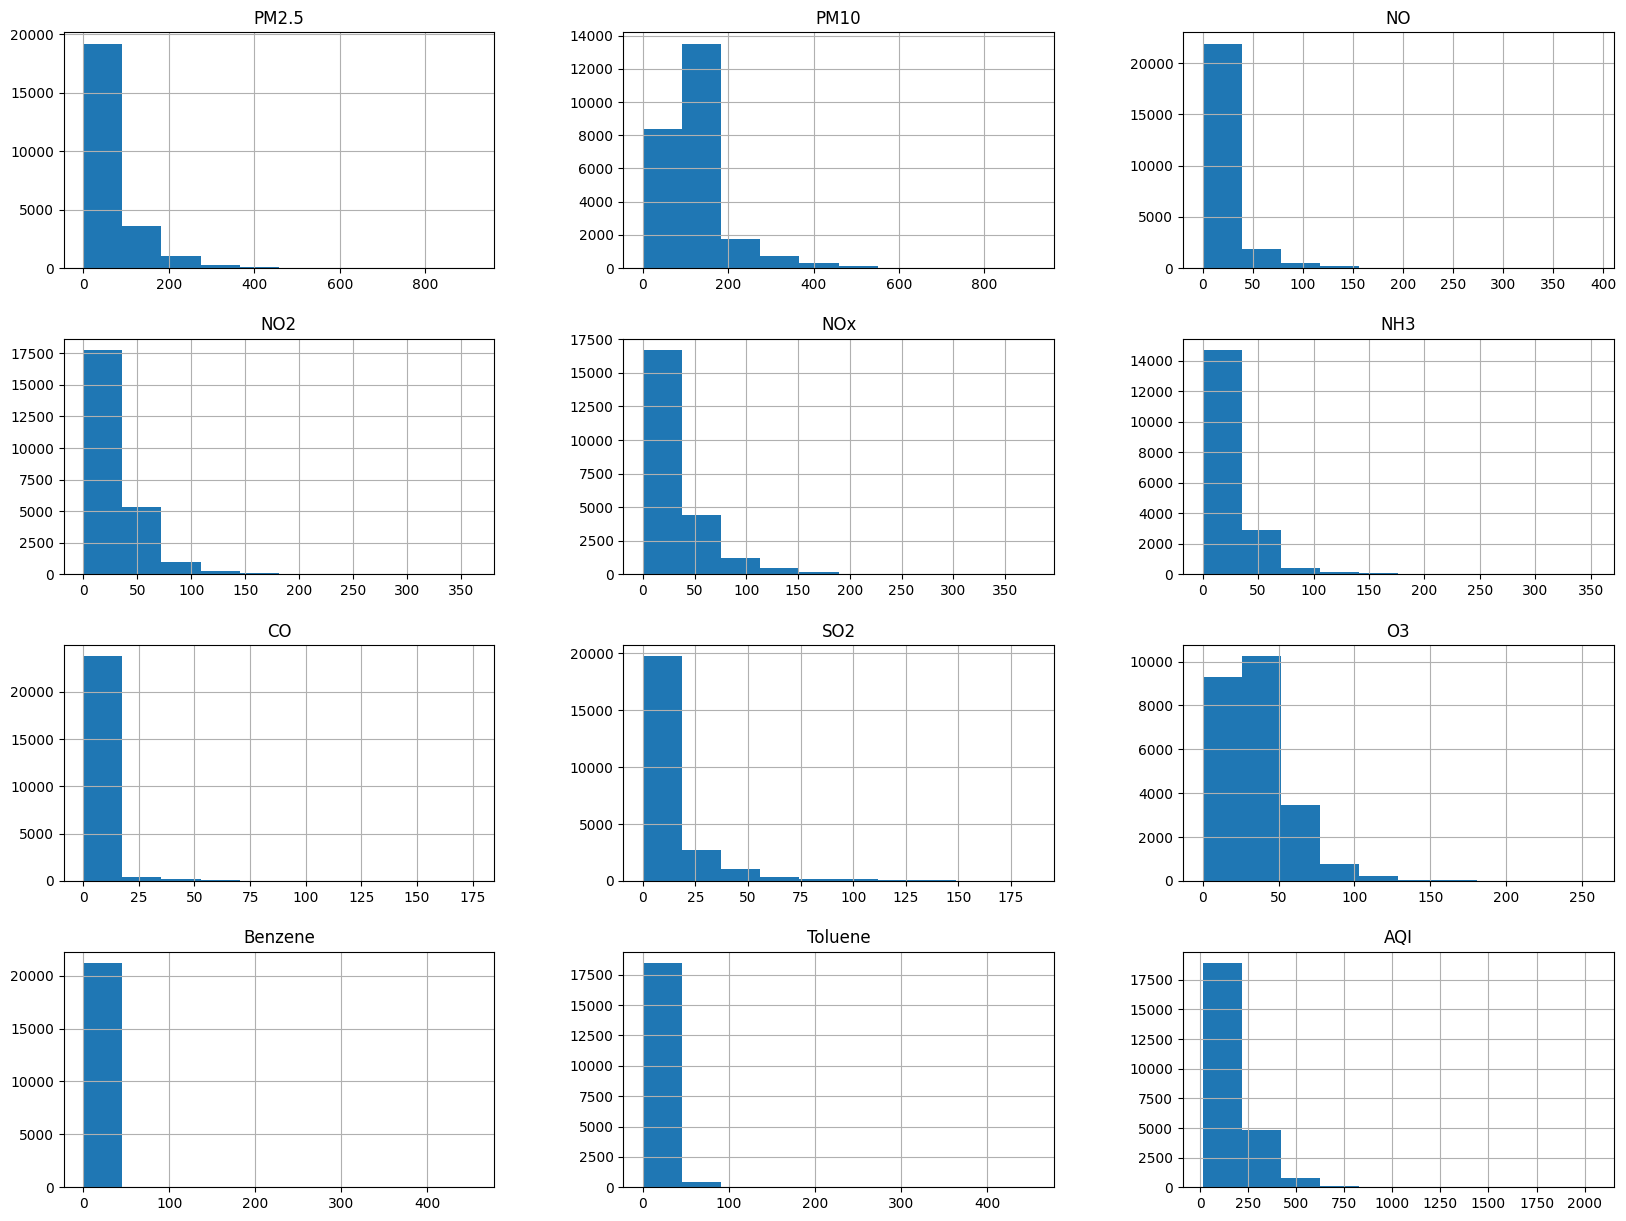

In [13]:
df.hist(figsize=(20, 15))
plt.show()

In [14]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    if col != "AQI":
        df[col] = df[col].fillna(df[col].median())

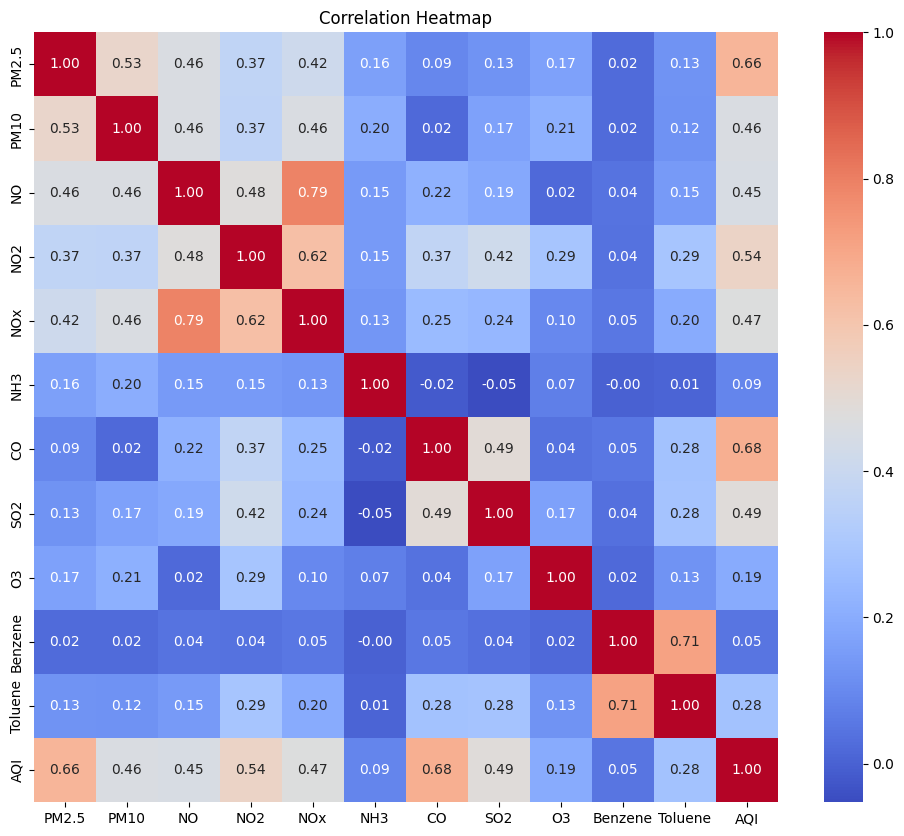

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket'],
      dtype='str')

In [17]:
df.drop(columns=["Date","City"],inplace=True)

df.columns

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'AQI', 'AQI_Bucket'],
      dtype='str')

In [18]:
df.drop(columns=["AQI_Bucket"], inplace=True) # Because this will Cause Data Leakage

In [19]:
df.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
28,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,209.0
29,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,328.0
30,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,514.0
31,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,782.0
32,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,914.0


In [20]:
df.isnull().sum()

PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
AQI        0
dtype: int64

In [21]:
x = df.drop(columns=['AQI'])
y = df['AQI']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(19880, 11)
(4970, 11)
(19880,)
(4970,)


In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
y_pred = rf.predict(X_test)

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 20.94
RMSE : 40.91
R²   : 0.9086


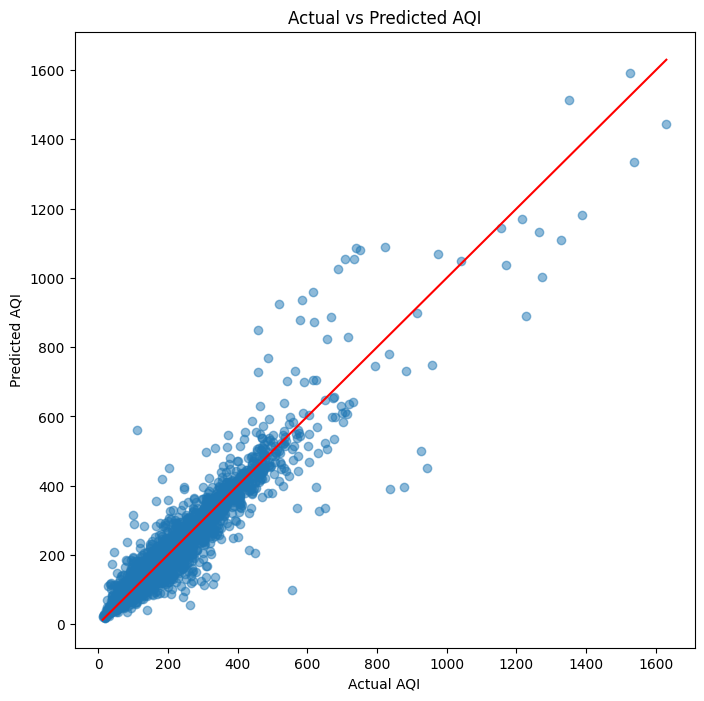

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

In [29]:
X_train.columns

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene'],
      dtype='str')

In [30]:
import pandas as pd

new_data = pd.DataFrame({
    "PM2.5": [95],
    "PM10": [160],
    "NO": [18],
    "NO2": [42],
    "NOx": [55],
    "NH3": [22],
    "CO": [1.8],
    "SO2": [14],
    "O3": [32],
    "Benzene": [4.5],
    "Toluene": [18]
})

In [31]:
prediction = rf.predict(new_data)

print(f"Predicted AQI: {prediction[0]:.2f}")

Predicted AQI: 229.95


In [32]:
def aqi_category(aqi):

    if aqi <= 50:
        return "Good 🟢"

    elif aqi <= 100:
        return "Satisfactory 🟡"

    elif aqi <= 200:
        return "Moderate 🟠"

    elif aqi <= 300:
        return "Poor 🔴"

    elif aqi <= 400:
        return "Very Poor 🟣"

    else:
        return "Severe ⚫"


pred = rf.predict(new_data)[0]

print("Predicted AQI :", round(pred,2))
print("Category :", aqi_category(pred))

Predicted AQI : 229.95
Category : Poor 🔴


In [33]:
sample = X_test.iloc[[0]]

print(sample)

      PM2.5   PM10    NO    NO2    NOx    NH3    CO   SO2     O3  Benzene  \
8450  42.37  96.18  4.37  15.42  16.21  16.31  1.03  4.94  36.09     0.76   

      Toluene  
8450     2.04  


In [34]:
prediction = rf.predict(sample)

print("Predicted AQI :", prediction[0])
print("Actual AQI :", y_test.iloc[0])

Predicted AQI : 98.38
Actual AQI : 141.0


In [35]:
comparison = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Predicted AQI": y_pred
})

comparison.head(20)

,Actual AQI,Predicted AQI
0,141.0,98.38
1,209.0,205.60
2,111.0,97.44
3,124.0,136.40
4,81.0,77.60
5,54.0,66.09
6,74.0,64.25
7,99.0,104.33
8,97.0,132.52
9,60.0,62.72


In [36]:
comparison["Error"] = abs(
    comparison["Actual AQI"] -
    comparison["Predicted AQI"]
)

comparison.head(20)

,Actual AQI,Predicted AQI,Error
0,141.0,98.38,42.62
1,209.0,205.60,3.40
2,111.0,97.44,13.56
3,124.0,136.40,12.40
4,81.0,77.60,3.40
5,54.0,66.09,12.09
6,74.0,64.25,9.75
7,99.0,104.33,5.33
8,97.0,132.52,35.52
9,60.0,62.72,2.72


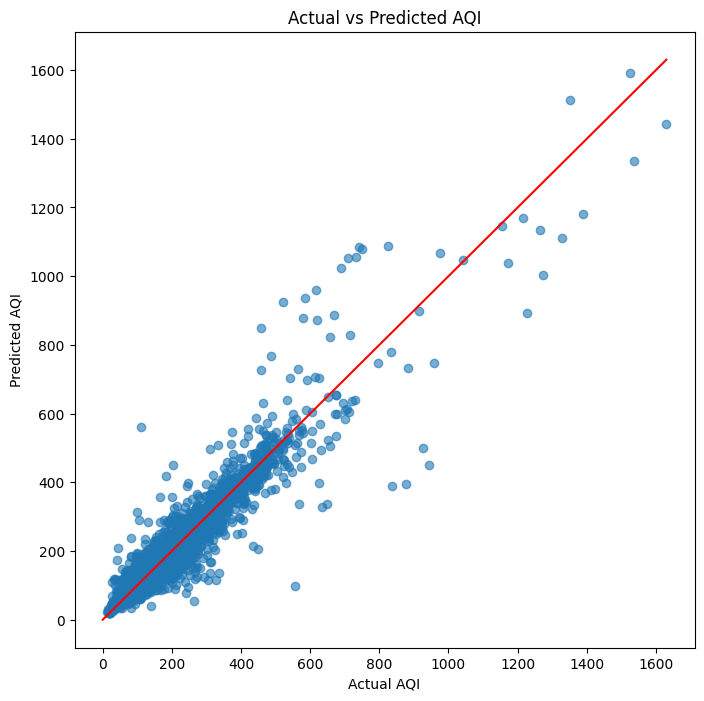

In [37]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [0, max(y_test)],
    [0, max(y_test)],
    color="red"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()